In [8]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/CV_lab5
%cd /content/CV_lab5

!mkdir -p datasets/svhn
!mkdir -p results
!mkdir -p my_photos
!mkdir -p report_images

print("Đã tạo xong thư mục")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/CV_lab5
Đã tạo xong thư mục


In [9]:
# Cài YOLOv8 và các thư viện cần thiết
!pip install -q ultralytics h5py pillow scipy matplotlib seaborn

from ultralytics import YOLO
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [10]:
import os

# Tải dữ liệu SVHN (bản đầy đủ)
!wget -q -P /content/CV_lab5 http://ufldl.stanford.edu/housenumbers/train.tar.gz
!wget -q -P /content/CV_lab5 http://ufldl.stanford.edu/housenumbers/test.tar.gz

# Giải nén
!tar -xzf /content/CV_lab5/train.tar.gz -C /content/CV_lab5
!tar -xzf /content/CV_lab5/test.tar.gz -C /content/CV_lab5

print("\n Train images:")
!ls /content/CV_lab5/train/ | head -10

print("\n Test images:")
!ls /content/CV_lab5/test/ | head -10

train_count = len([f for f in os.listdir("/content/CV_lab5/train") if f.endswith('.png')])
test_count = len([f for f in os.listdir("/content/CV_lab5/test") if f.endswith('.png')])
print(f"\nTrain: {train_count}")
print(f" Test: {test_count}")


 Train images:
10000.png
10001.png
10002.png
10003.png
10004.png
10005.png
10006.png
10007.png
10008.png
10009.png

 Test images:
10000.png
10001.png
10002.png
10003.png
10004.png
10005.png
10006.png
10007.png
10008.png
10009.png

Train: 33402
 Test: 13068


In [11]:
import h5py
import numpy as np
from PIL import Image
import shutil
import glob
import os

def parse_svhn_annotations(annotation_file, source_image_dir, destination_root):
    """
    Đọc file digitStruct.mat và chuyển đổi sang format YOLO
    """
    images_dest = os.path.join(destination_root, "images")
    labels_dest = os.path.join(destination_root, "labels")
    os.makedirs(images_dest, exist_ok=True)
    os.makedirs(labels_dest, exist_ok=True)

    with h5py.File(annotation_file, "r") as h5_data:
        struct_data = h5_data["digitStruct"]
        image_names = struct_data["name"]
        bounding_boxes = struct_data["bbox"]

        def extract_number(ref_obj):
            """Trích xuất giá trị số từ reference hoặc số thông thường"""
            if isinstance(ref_obj, h5py.Reference):
                return float(h5_data[ref_obj][0][0])
            return float(ref_obj)

        def collect_attributes(box_obj, attribute_name):
            """Thu thập các thuộc tính của bounding box"""
            attr_data = box_obj[attribute_name]
            values = []
            for idx in range(len(attr_data)):
                values.append(extract_number(attr_data[idx][0]))
            return values

        processed_count = 0

        for idx in range(len(image_names)):
            # Lấy tên file ảnh
            name_ref = image_names[idx][0]
            image_filename = "".join(chr(c) for c in h5_data[name_ref][:].flatten())

            source_path = os.path.join(source_image_dir, image_filename)
            if not os.path.exists(source_path):
                continue

            # Đọc kích thước ảnh gốc
            with Image.open(source_path) as pil_image:
                orig_width, orig_height = pil_image.size

            # Lấy thông tin bounding boxes
            box_obj = h5_data[bounding_boxes[idx][0]]
            class_ids = collect_attributes(box_obj, "label")
            x_coords = collect_attributes(box_obj, "left")
            y_coords = collect_attributes(box_obj, "top")
            box_widths = collect_attributes(box_obj, "width")
            box_heights = collect_attributes(box_obj, "height")

            # Ghi file label theo format YOLO
            label_file = os.path.join(labels_dest, os.path.splitext(image_filename)[0] + ".txt")
            with open(label_file, "w") as f_out:
                for j in range(len(class_ids)):
                    category = int(class_ids[j])
                    if category == 10:  # Chuyển đổi label 10 -> 0
                        category = 0
                    if category < 0 or category > 9:
                        continue

                    # Chuẩn hóa tọa độ về [0, 1]
                    center_x = (x_coords[j] + box_widths[j] / 2) / orig_width
                    center_y = (y_coords[j] + box_heights[j] / 2) / orig_height
                    norm_width = box_widths[j] / orig_width
                    norm_height = box_heights[j] / orig_height

                    # Giới hạn giá trị trong khoảng [0, 1]
                    center_x = max(0, min(1, center_x))
                    center_y = max(0, min(1, center_y))
                    norm_width = max(0, min(1, norm_width))
                    norm_height = max(0, min(1, norm_height))

                    if norm_width <= 0 or norm_height <= 0:
                        continue

                    f_out.write(f"{category} {center_x:.6f} {center_y:.6f} {norm_width:.6f} {norm_height:.6f}\n")

            # Sao chép ảnh vào thư mục đích
            shutil.copy(source_path, os.path.join(images_dest, image_filename))
            processed_count += 1

            if (idx + 1) % 5000 == 0:
                print(f"   Đã xử lý: {idx + 1} ảnh")

    print(f"Hoàn thành: {processed_count} ảnh đã được xử lý => {destination_root}")
    return processed_count


print("BẮT ĐẦU XỬ LÝ TẬP TRAIN")
train_result = parse_svhn_annotations(
    "/content/CV_lab5/train/digitStruct.mat",
    "/content/CV_lab5/train",
    "/content/CV_lab5/datasets/svhn/train"
)

print("BẮT ĐẦU XỬ LÝ TẬP TEST")
test_result = parse_svhn_annotations(
    "/content/CV_lab5/test/digitStruct.mat",
    "/content/CV_lab5/test",
    "/content/CV_lab5/datasets/svhn/test"
)

print(f"Số ảnh train đã convert: {train_result}")
print(f"Số ảnh test đã convert: {test_result}")
print(f"Thư mục output: /content/CV_lab5/datasets/svhn/")

BẮT ĐẦU XỬ LÝ TẬP TRAIN
   Đã xử lý: 5000 ảnh
   Đã xử lý: 10000 ảnh
   Đã xử lý: 15000 ảnh
   Đã xử lý: 20000 ảnh
   Đã xử lý: 25000 ảnh
   Đã xử lý: 30000 ảnh
Hoàn thành: 33402 ảnh đã được xử lý => /content/CV_lab5/datasets/svhn/train
BẮT ĐẦU XỬ LÝ TẬP TEST
   Đã xử lý: 5000 ảnh
   Đã xử lý: 10000 ảnh
Hoàn thành: 13068 ảnh đã được xử lý => /content/CV_lab5/datasets/svhn/test
Số ảnh train đã convert: 33402
Số ảnh test đã convert: 13068
Thư mục output: /content/CV_lab5/datasets/svhn/


Tạo file cấu hình yaml

In [12]:
yaml_content = f"""
path: /content/CV_lab5/datasets/svhn
train: train/images
val: test/images

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
"""

with open("/content/CV_lab5/svhn.yaml", "w") as f:
    f.write(yaml_content)

print("Đã tạo file svhn.yaml")
print("\nNội dung file:")
print(yaml_content)

Đã tạo file svhn.yaml

Nội dung file:

path: /content/CV_lab5/datasets/svhn
train: train/images
val: test/images

nc: 10
names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']



# Huấn luyện model

In [13]:
from ultralytics import YOLO
import time

# Chọn số epochs (có thể tăng lên 30-50-100 nếu có thời gian)
EPOCHS = 10  #có thể sửa thành 50 hoặc 100

print(f"Bắt đầu huấn luyện với {EPOCHS} epochs...")
start_time = time.time()

# Load pretrained model
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data="/content/CV_lab5/svhn.yaml",
    epochs=EPOCHS,
    imgsz=640,
    batch=32,
    device=0,
    project="/content/CV_lab5/runs/detect",
    name="svhn_10class",
    exist_ok=True,
    patience=5,  # Early stopping nếu không cải thiện sau 5 epochs
    lr0=0.01,
    warmup_epochs=3
)

end_time = time.time()
print(f"\nHoàn thành huấn luyện trong {(end_time - start_time)/60:.2f} phút")

Bắt đầu huấn luyện với 10 epochs...
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CV_lab5/svhn.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=svhn_10class, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [15]:
# Đánh giá model từ test set
#Tìm model tốt nhất
import glob

best_path = "/content/CV_lab5/runs/detect/svhn_10class/weights/best.pt"
print(f" Load model từ: {best_path}")

best_model = YOLO(best_path)

# Đánh giá
metrics = best_model.val(
    data="/content/CV_lab5/svhn.yaml",
    imgsz=640,
    batch=32,
    device=0,
    plots=True,  # Tự động vẽ biểu đồ
    save_json=True
)

# In kết quả
print("KẾT QUẢ ĐÁNH GIÁ TRÊN SVHN TEST SET")
print(f"Precision (mP):  {metrics.box.mp:.4f}")
print(f"Recall (mR):     {metrics.box.mr:.4f}")
print(f"mAP@0.5:         {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:    {metrics.box.map:.4f}")

# Lưu kết quả vào file
with open("/content/CV_lab5/results/metrics.txt", "w") as f:
    f.write(f"Precision: {metrics.box.mp:.4f}\n")
    f.write(f"Recall: {metrics.box.mr:.4f}\n")
    f.write(f"mAP50: {metrics.box.map50:.4f}\n")
    f.write(f"mAP50-95: {metrics.box.map:.4f}\n")

print("\nĐã lưu metrics vào /content/CV_lab5/results/metrics.txt")

 Load model từ: /content/CV_lab5/runs/detect/svhn_10class/weights/best.pt
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 323.5±385.6 MB/s, size: 32.9 KB)
val: Scanning /content/CV_lab5/datasets/svhn/test/labels.cache... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 2.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 409/409 4.0it/s 1:43
                   all      13068      26032      0.892      0.842      0.891      0.421
                     0       1687       1744      0.874      0.896      0.918      0.448
                     1       4578       5099      0.868      0.754      0.829       0.34
                     2       3834       4149      0.901      0.869      0.906      0.439
                     3       2696       2882 

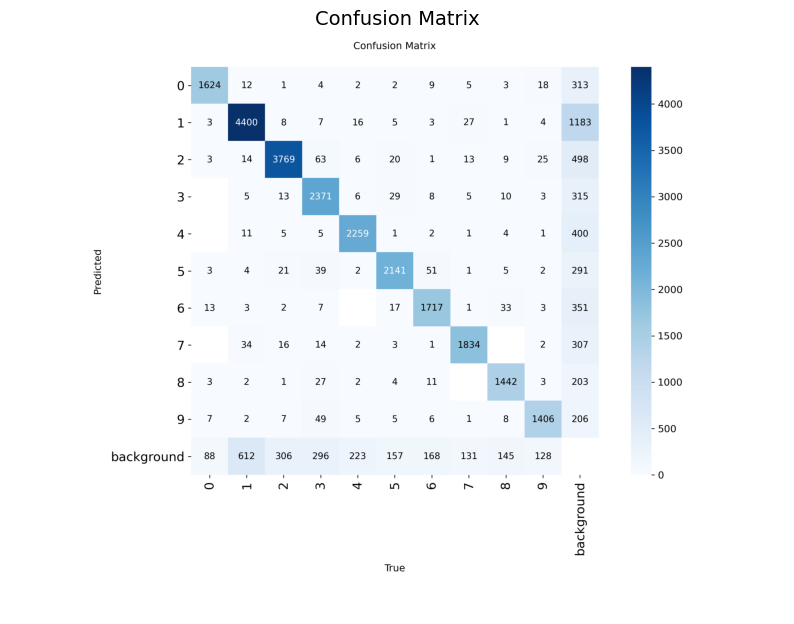

Đã lưu confusion matrix


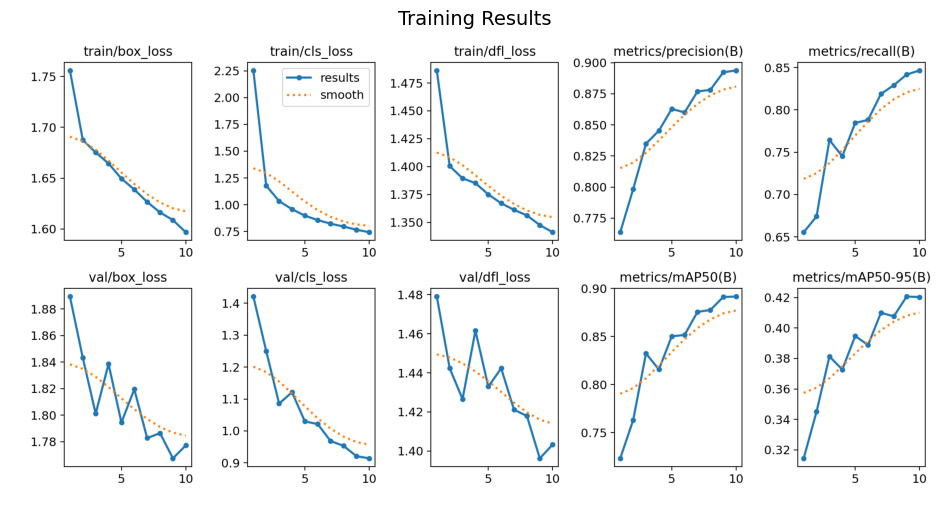

Đã lưu training results


In [16]:
import matplotlib.pyplot as plt
import cv2

# Đọc confusion matrix
cm_path = "/content/CV_lab5/runs/detect/svhn_10class/confusion_matrix.png"
if os.path.exists(cm_path):
    img = cv2.imread(cm_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title("Confusion Matrix", fontsize=14)
    plt.axis('off')
    plt.savefig("/content/CV_lab5/report_images/confusion_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu confusion matrix")

# Đọc PR curve
pr_path = "/content/CV_lab5/runs/detect/svhn_10class/PR_curve.png"
if os.path.exists(pr_path):
    img = cv2.imread(pr_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title("Precision-Recall Curve", fontsize=14)
    plt.axis('off')
    plt.savefig("/content/CV_lab5/report_images/pr_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu PR curve")

# Đọc results plot
results_path = "/content/CV_lab5/runs/detect/svhn_10class/results.png"
if os.path.exists(results_path):
    img = cv2.imread(results_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.title("Training Results", fontsize=14)
    plt.axis('off')
    plt.savefig("/content/CV_lab5/report_images/training_results.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu training results")

In [39]:
from google.colab import files, output
import os
import time

print(" Đang mở cửa sổ chọn file...")
time.sleep(1)

# Upload
uploaded = files.upload()

# Xóa toàn bộ output cũ
output.clear()


for filename in uploaded.keys():
    os.rename(filename, f"/content/CV_lab5/my_photos/{filename}")
    print(f"    {filename}")

print(f"\n Thành công! {len(uploaded)} ảnh đã được tải lên")

    photo_5224381722345019125_x.jpg
    photo_5224381722345019126_x.jpg
    photo_5224381722345019127_x.jpg
    photo_5224381722345019128_x.jpg
    photo_5224381722345019129_x.jpg
    photo_5224381722345019131_y.jpg
    photo_5224381722345019132_x.jpg
    photo_5224381722345019133_x.jpg
    photo_5224381722345019135_x.jpg
    photo_5224381722345019136_x.jpg
    photo_5224381722345019138_m.jpg
    photo_5224381722345019140_y.jpg
    photo_5224381722345019141_y.jpg
    photo_5224381722345019142_x.jpg
    photo_5224381722345019144_x.jpg
    photo_5224692450343983781_y.jpg
    photo_5224692450343983782_y.jpg
    photo_5224692450343983783_y.jpg
    photo_5224692450343983784_x.jpg
    photo_5224692450343983785_x.jpg
    photo_5224692450343983786_x.jpg
    photo_5224692450343983787_x.jpg
    photo_5224692450343983788_x.jpg
    photo_5224692450343983789_x.jpg
    photo_5224692450343983790_m.jpg
    photo_5224692450343983791_x.jpg

 Thành công! 26 ảnh đã được tải lên


In [40]:
# Chạy detection trên ảnh tự chụp
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np

# Load model tốt nhất
best_model = YOLO("/content/CV_lab5/runs/detect/svhn_10class/weights/best.pt")

# Lấy danh sách ảnh
image_files = glob.glob("/content/CV_lab5/my_photos/*.jpg") + \
              glob.glob("/content/CV_lab5/my_photos/*.png") + \
              glob.glob("/content/CV_lab5/my_photos/*.jpeg")

print(f"Tìm thấy {len(image_files)} ảnh")

results_list = []

# Predict từng ảnh
for img_path in image_files:
    # Predict
    results = best_model.predict(
        source=img_path,
        conf=0.35,  # Confidence threshold
        iou=0.45,   # NMS IoU threshold
        imgsz=640,
        device=0,
        save=False,
        save_txt=False
    )

    # Lấy ảnh kết quả
    for r in results:
        # Vẽ bounding boxes
        im_array = r.plot()
        im_array = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

        # Lưu kết quả
        base_name = os.path.basename(img_path)
        save_path = f"/content/CV_lab5/results/detected_{base_name}"
        plt.figure(figsize=(10, 10))
        plt.imshow(im_array)
        plt.axis('off')
        plt.title(f"Detection Result: {base_name}", fontsize=12)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

        results_list.append({
            'image': base_name,
            'num_detections': len(r.boxes) if r.boxes else 0,
            'save_path': save_path
        })

        print(f"{base_name}: {len(r.boxes) if r.boxes else 0} số được phát hiện")

print(f"\nĐã detect xong {len(results_list)} ảnh")

Tìm thấy 26 ảnh

image 1/1 /content/CV_lab5/my_photos/photo_5224692450343983781_y.jpg: 416x640 (no detections), 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 640)
photo_5224692450343983781_y.jpg: 0 số được phát hiện

image 1/1 /content/CV_lab5/my_photos/photo_5224381722345019142_x.jpg: 640x448 1 0, 1 1, 8.4ms
Speed: 2.5ms preprocess, 8.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 448)
photo_5224381722345019142_x.jpg: 2 số được phát hiện

image 1/1 /content/CV_lab5/my_photos/photo_5224381722345019136_x.jpg: 384x640 4 0s, 1 2, 1 8, 7.9ms
Speed: 2.0ms preprocess, 7.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
photo_5224381722345019136_x.jpg: 6 số được phát hiện

image 1/1 /content/CV_lab5/my_photos/photo_5224381722345019128_x.jpg: 448x640 1 2, 1 7, 11.8ms
Speed: 2.7ms preprocess, 11.8ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
photo_5224381722345019128_x.jpg: 2 số được phá

Tìm thấy 26 ảnh kết quả


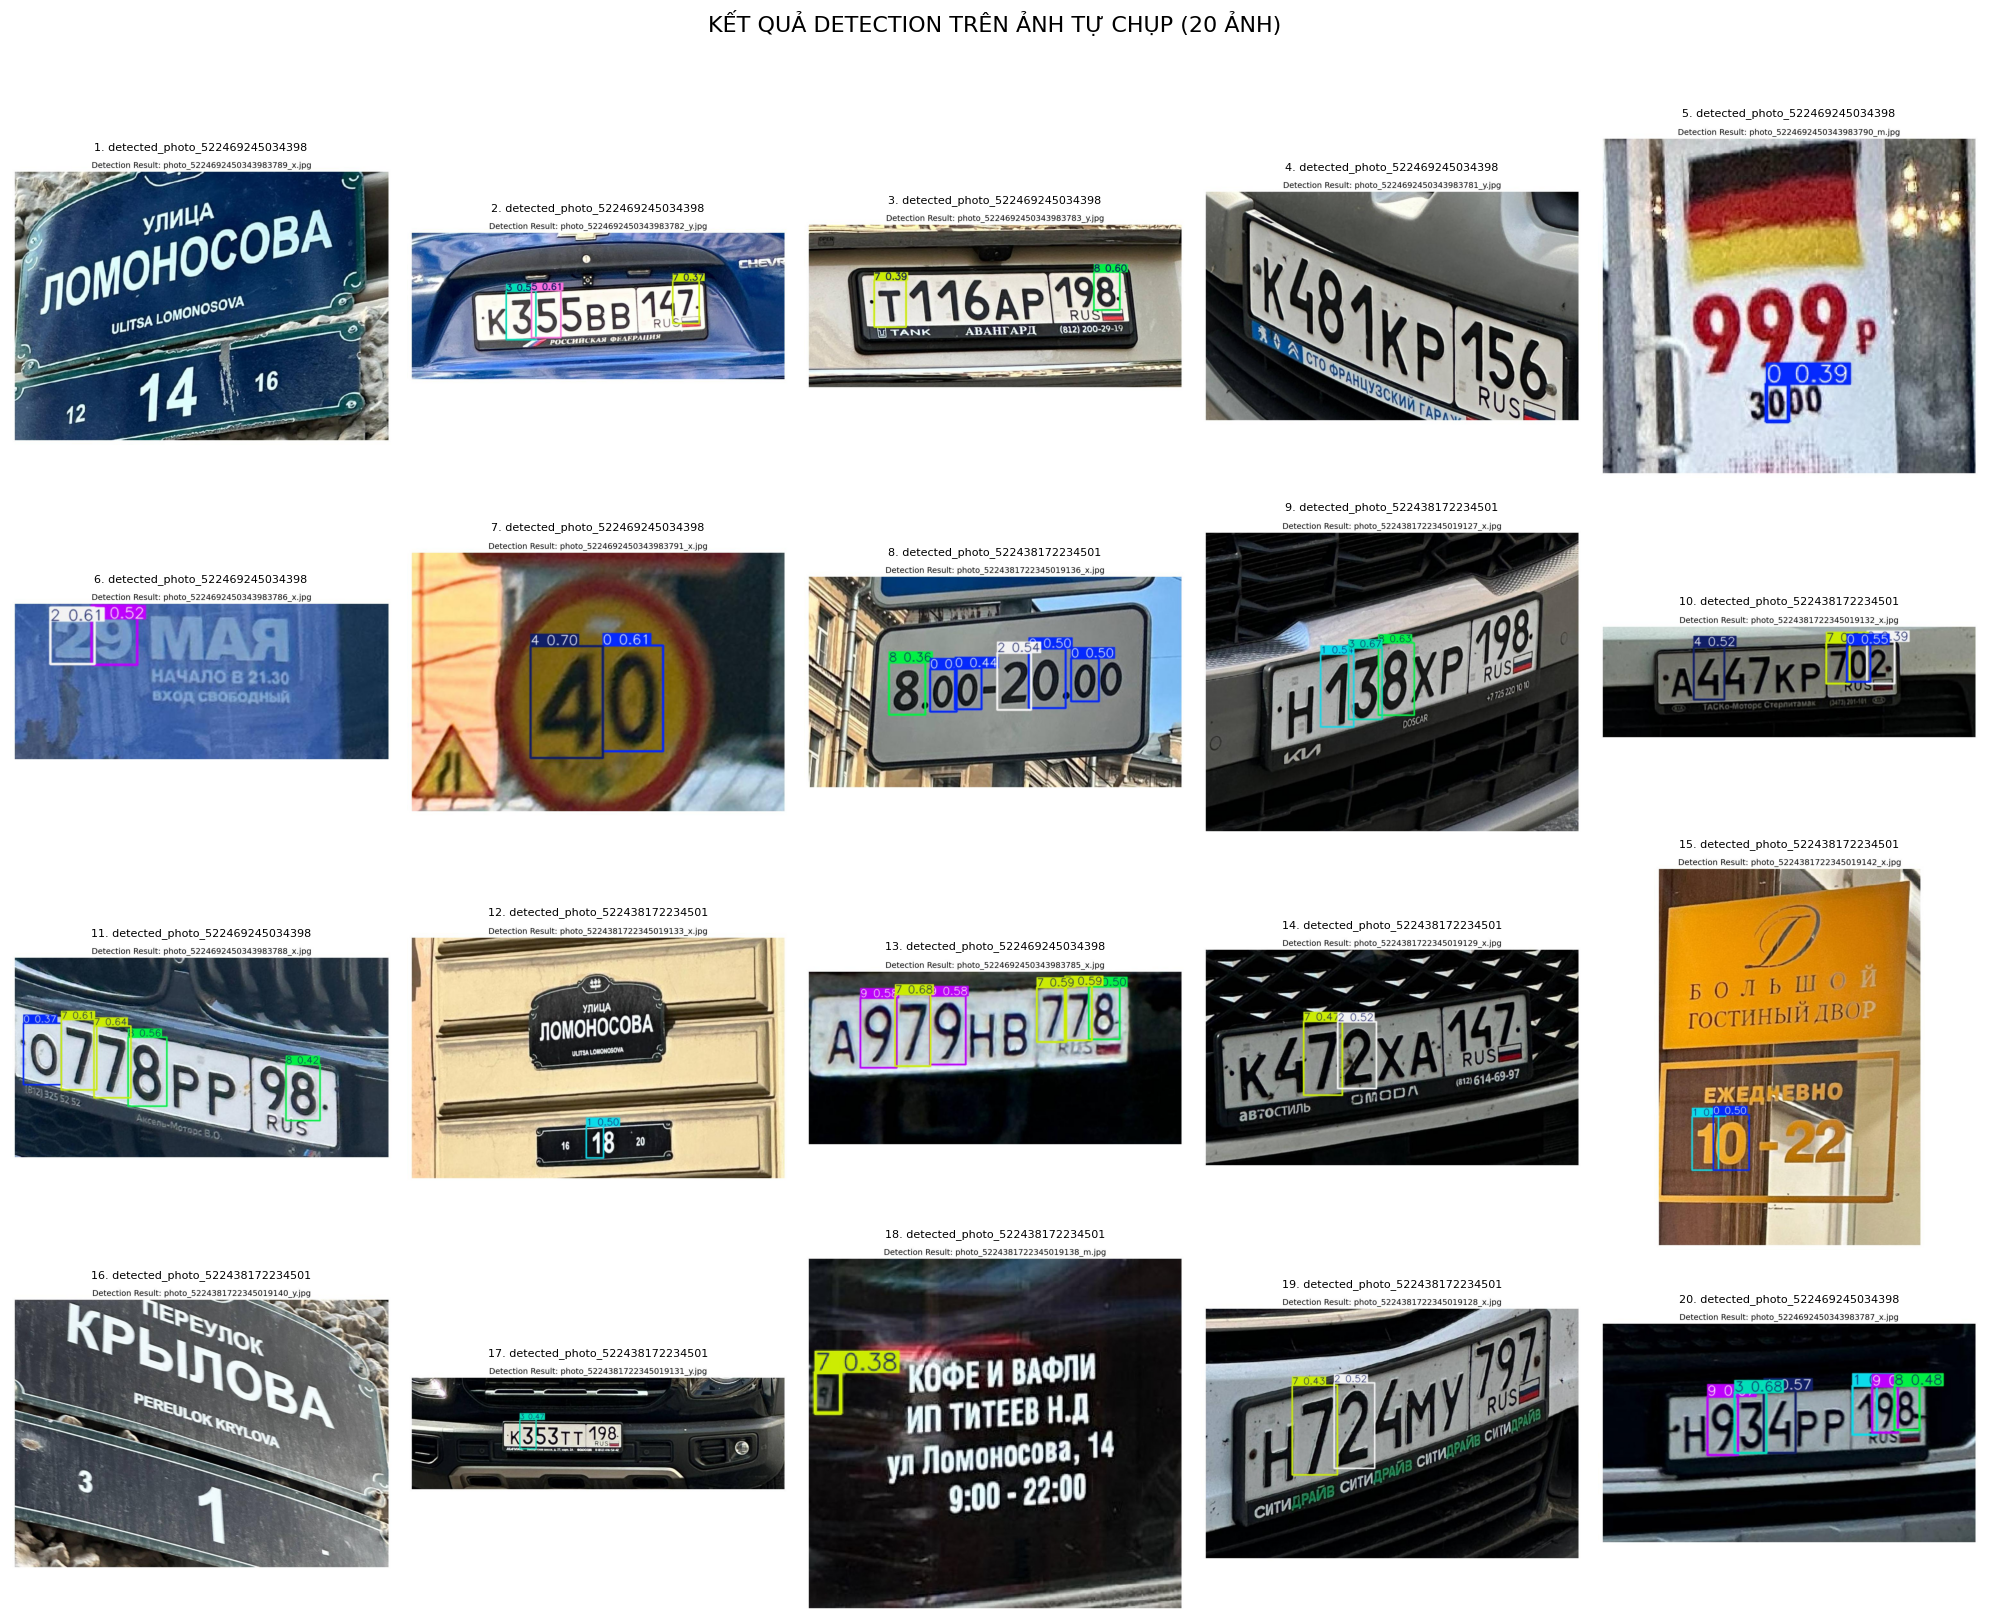


 Đã hiển thị 20 ảnh
 Đã lưu grid ảnh tại: /content/CV_lab5/report_images/20_detection_results.png
   Tổng số ảnh đã detect: 26
   Số ảnh hiển thị: 20


In [41]:
# HIỂN THỊ 20 ẢNH KẾT QUẢ DETECTION
import glob
import cv2
import matplotlib.pyplot as plt

# Lấy danh sách ảnh kết quả đã lưu
result_images = glob.glob("/content/CV_lab5/results/detected_*.jpg")

print(f"Tìm thấy {len(result_images)} ảnh kết quả")

if result_images:
    # Chọn tối đa 20 ảnh
    display_count = min(20, len(result_images))
    display_images = result_images[:display_count]

    # Tạo grid (4 hàng x 5 cột = 20 ảnh)
    n_cols = 5
    n_rows = (display_count + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()

    for i, img_path in enumerate(display_images):
        # Đọc ảnh
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Hiển thị
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"{i+1}. {os.path.basename(img_path)[:30]}", fontsize=8)

    # Ẩn các subplot thừa
    for i in range(display_count, len(axes)):
        axes[i].axis('off')

    plt.suptitle(f"KẾT QUẢ DETECTION TRÊN ẢNH TỰ CHỤP ({display_count} ẢNH)", fontsize=16, y=1.02)
    plt.tight_layout()

    # Lưu grid ảnh
    plt.savefig("/content/CV_lab5/report_images/20_detection_results.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n Đã hiển thị {display_count} ảnh")
    print(f" Đã lưu grid ảnh tại: /content/CV_lab5/report_images/20_detection_results.png")

    # In thống kê
    print(f"   Tổng số ảnh đã detect: {len(result_images)}")
    print(f"   Số ảnh hiển thị: {display_count}")
else:
    print(" Không tìm thấy ảnh kết quả nào trong thư mục results/")